In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
nav = pd.read_csv("../data/processed/nav_history_clean.csv")

In [3]:
nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [4]:
nav.columns

Index(['amfi_code', 'date', 'nav'], dtype='object')

In [5]:
nav["date"] = pd.to_datetime(nav["date"])

In [6]:
nav = nav.sort_values(["amfi_code", "date"])

In [7]:
nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

In [8]:
nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [9]:
results = []

for code, group in nav.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    var95 = returns.quantile(0.05)

    cvar95 = returns[returns <= var95].mean()

    results.append({
        "amfi_code": code,
        "VaR_95": var95,
        "CVaR_95": cvar95
    })

var_cvar = pd.DataFrame(results)

In [10]:
var_cvar.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [11]:
var_cvar.to_csv("../reports/var_cvar_report.csv", index=False)

In [12]:
nav["date"] = pd.to_datetime(nav["date"])

In [13]:
nav = nav.sort_values(["amfi_code", "date"])

In [14]:
nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

In [15]:
nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [16]:
results = []

for code, group in nav.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    var95 = returns.quantile(0.05)

    cvar95 = returns[returns <= var95].mean()

    results.append({
        "amfi_code": code,
        "VaR_95": var95,
        "CVaR_95": cvar95
    })

var_cvar = pd.DataFrame(results)

In [17]:
var_cvar

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459
5,101208,-0.000269,-0.000422
6,102885,-0.012613,-0.015490
7,102886,-0.019220,-0.023251
8,102887,-0.015232,-0.019411
9,118632,-0.013954,-0.017619


In [18]:
var_cvar.to_csv("../reports/var_cvar_report.csv", index=False)

print("Saved successfully!")

Saved successfully!


In [19]:
import numpy as np

In [20]:
rolling_sharpe = (
    nav.groupby("amfi_code")["daily_return"]
       .rolling(90)
       .mean()
    /
    nav.groupby("amfi_code")["daily_return"]
       .rolling(90)
       .std()
) * np.sqrt(252)

rolling_sharpe = rolling_sharpe.reset_index()

In [21]:
rolling_sharpe.head()

,amfi_code,level_1,daily_return
0,100016,0,NaN
1,100016,1,NaN
2,100016,2,NaN
3,100016,3,NaN
4,100016,4,NaN


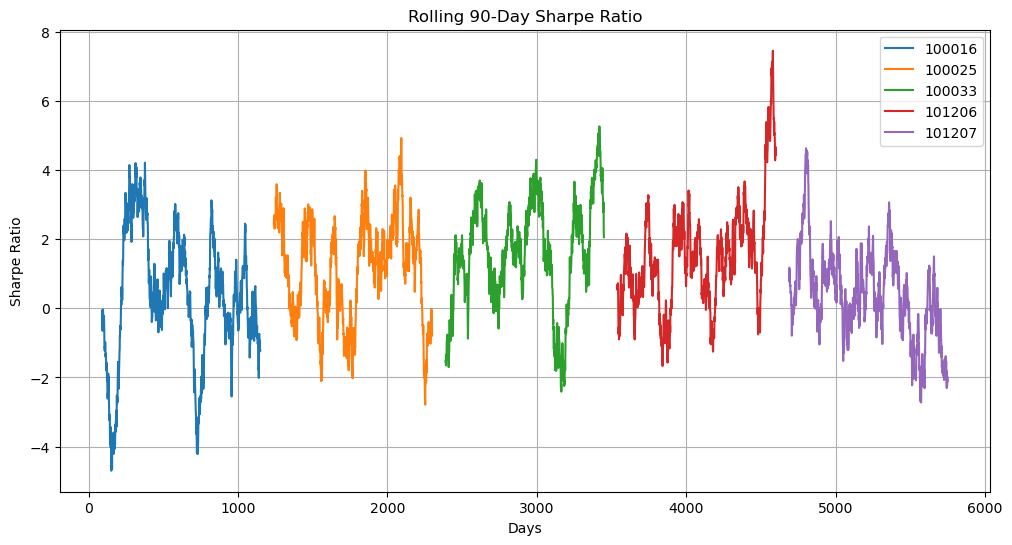

In [22]:
top5 = rolling_sharpe["amfi_code"].unique()[:5]

plt.figure(figsize=(12,6))

for code in top5:
    data = rolling_sharpe[rolling_sharpe["amfi_code"] == code]
    plt.plot(data.index, data["daily_return"], label=str(code))

plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Days")
plt.ylabel("Sharpe Ratio")
plt.legend()
plt.grid(True)

plt.savefig("../reports/rolling_sharpe_chart.png")
plt.show()

In [23]:
import pandas as pd

transactions = pd.read_csv("../data/processed/investor_transactions_clean.csv")
transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,Sip,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,Sip,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,Sip,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [24]:
transactions["transaction_date"] = pd.to_datetime(transactions["transaction_date"])

In [25]:
cohort = transactions.groupby("investor_id")["transaction_date"].min().reset_index()
cohort["cohort_year"] = cohort["transaction_date"].dt.year

transactions = transactions.merge(
    cohort[["investor_id", "cohort_year"]],
    on="investor_id"
)

In [26]:
cohort_summary = transactions.groupby("cohort_year").agg(
    avg_sip=("amount_inr", "mean"),
    total_invested=("amount_inr", "sum")
)

cohort_summary

,avg_sip,total_invested
cohort_year,,
2024,107422.541832,3491125187
2025,109158.577061,30455243


In [27]:
top_fund = (
    transactions.groupby(["cohort_year", "amfi_code"])
    .size()
    .reset_index(name="count")
)

top_fund = top_fund.sort_values(
    ["cohort_year", "count"],
    ascending=[True, False]
)

top_fund = top_fund.groupby("cohort_year").first()

top_fund

,amfi_code,count
cohort_year,,
2024,148568,874
2025,119599,12


In [28]:
sip = transactions[
    transactions["transaction_type"] == "SIP"
].copy()

In [29]:
sip = transactions[transactions["transaction_type"] == "SIP"].copy()

sip.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year


In [30]:
sip = sip.sort_values(["investor_id", "transaction_date"])

In [31]:
sip["gap_days"] = sip.groupby("investor_id")["transaction_date"].diff().dt.days

sip.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year,gap_days


In [32]:
sip_count = sip.groupby("investor_id").size()

eligible = sip_count[sip_count >= 6].index

sip_eligible = sip[sip["investor_id"].isin(eligible)]

In [33]:
gap_summary = sip_eligible.groupby("investor_id")["gap_days"].mean().reset_index()

gap_summary.rename(columns={"gap_days": "avg_gap_days"}, inplace=True)

gap_summary.head()

,investor_id,avg_gap_days


In [34]:
gap_summary["status"] = gap_summary["avg_gap_days"].apply(
    lambda x: "At-Risk" if x > 35 else "Regular"
)

gap_summary.head()

,investor_id,avg_gap_days,status


In [35]:
gap_summary.to_csv("../reports/sip_continuity_report.csv", index=False)

print("Saved successfully!")

Saved successfully!
